In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


In [2]:
# Load Dollars Bars
path = Path("../data/es_dollar_bars.csv")

if not path.exists():
    raise FileNotFoundError(
        f"File not found: {path}"
    )

bars = pd.read_csv(path, parse_dates=["timestamp"])
bars = bars.sort_values("timestamp").reset_index(drop=True)

print("Rows:", len(bars))
print("Start:", bars["timestamp"].min())
print("End:", bars["timestamp"].max())


display(bars.head())

Rows: 149
Start: 2013-09-01 17:19:56.232000
End: 2013-09-03 13:49:06.359000


,ticks,open,high,low,close,volume,dollar_value,timestamp
0,2837,1640.25,1642.0,1639.00,1640.50,12342.0,1.012227e+09,2013-09-01 17:19:56.232
1,3224,1640.25,1642.0,1639.75,1640.75,12303.0,1.009461e+09,2013-09-01 19:09:34.288
2,3396,1640.75,1643.5,1640.75,1642.50,12292.0,1.009253e+09,2013-09-01 20:22:59.983
3,4190,1642.50,1644.0,1640.25,1643.00,12293.0,1.009345e+09,2013-09-02 00:00:47.925
4,4706,1643.00,1644.5,1642.00,1643.50,12283.0,1.009180e+09,2013-09-02 02:00:46.464


In [3]:
# close price series
close = bars.set_index("timestamp")["close"].sort_index()
display(close.head())

timestamp
2013-09-01 17:19:56.232    1640.50
2013-09-01 19:09:34.288    1640.75
2013-09-01 20:22:59.983    1642.50
2013-09-02 00:00:47.925    1643.00
2013-09-02 02:00:46.464    1643.50
Name: close, dtype: float64

In [4]:
# daily volatility
def get_daily_volatility(close, span=100):
    idx = close.index.searchsorted(
        close.index - pd.Timedelta(days=1)
    )
    
    idx = idx[idx > 0]

    prev_idx = pd.Series(
      close.index[idx - 1],
      index=close.index[close.shape[0] - idx.shape[0]:]
    )

    daily_ret = (
      close.loc[prev_idx.index].values /
      close.loc[prev_idx.values].values
      - 1
    )

    daily_ret = pd.Series(
      daily_ret,
      index=prev_idx.index
    )

    return daily_ret.ewm(span=span).std()

In [ ]:
# Calculate and display daily volatility
daily_vol = get_daily_volatility(close, span=100)

print("Daily volatility observations:", daily_vol.notna().sum())
display(daily_vol.dropna().head())

Daily volatility observations: 133


timestamp
2013-09-02 21:53:56.628    0.000541
2013-09-03 00:12:57.042    0.000383
2013-09-03 02:02:41.206    0.000312
2013-09-03 02:25:43.889    0.000790
2013-09-03 02:58:19.615    0.000760
dtype: float64

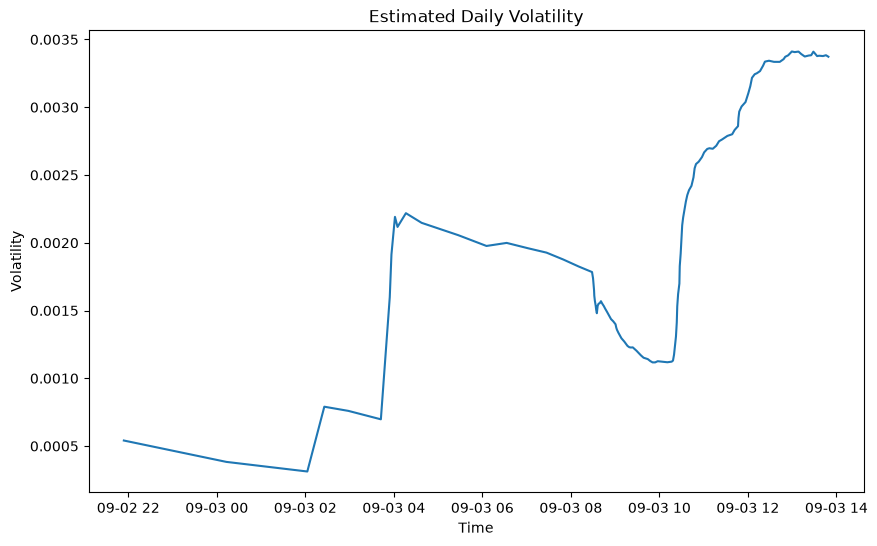

In [6]:
# plot daily volatility
plt.figure(figsize=(10, 6))
plt.plot(daily_vol.index, daily_vol)
plt.title("Estimated Daily Volatility")
plt.xlabel("Time")
plt.ylabel("Volatility")
plt.show()

### CUSUM Filter
Cusum identifies points where cumulative returns move far enough away from sero to count as an event

In [ ]:
# CUSUM function
def cusum_filter(close, threshold):
    log_ret = np.log(close).diff().dropna()

    s_pos, s_neg = 0, 0
    events = []

    for t in log_ret.index:
        if t not in threshold.index:
            continue

        h = threshold.loc[t]

        if pd.isna(h) or h <= 0:
            continue

        value = log_ret.loc[t]

        s_pos = max(0, s_pos + value)
        s_neg = min(0, s_neg + value)

        if s_pos > h:
            events.append(t)
            s_pos = 0
        elif s_neg < -h:
            events.append(t)
            s_neg = 0

    return pd.DatetimeIndex(events)